In [11]:
# Cài đặt các thư viện cần thiết
import sys
!{sys.executable} -m pip install -q wordcloud matplotlib

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [12]:
# Import thư viện và cấu hình đường dẫn
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- Thêm đường dẫn gốc của dự án vào sys.path ---
# Điều này đảm bảo notebook có thể tìm thấy và import module `rag`
# Sử dụng một đường dẫn tuyệt đối để đảm bảo tính ổn định
project_root = Path(r"C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
# ----------------------------------------------------

# Import hàm chunking đã tạo
from rag.chunking import get_text_chunks

print(f"Đã thêm đường dẫn gốc vào sys.path: {project_root}")
print("Tất cả thư viện đã sẵn sàng!")

Đã thêm đường dẫn gốc vào sys.path: C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot
Tất cả thư viện đã sẵn sàng!


## 1. Đọc dữ liệu và tạo Chunks

Đọc toàn bộ nội dung từ file `corpus_raw.txt` và sử dụng hàm `get_text_chunks` để chia thành danh sách các chunk.

In [13]:
# Xác định đường dẫn và đọc file
BASE_DIR = project_root
RAW_CORPUS_PATH = BASE_DIR / "data" / "processed" / "corpus_raw.txt"

print(f"Đang đọc dữ liệu từ: {RAW_CORPUS_PATH}")
with open(RAW_CORPUS_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

# Sử dụng hàm để tạo chunks
# Các tham số chunk_size và chunk_overlap có thể điều chỉnh để xem kết quả khác nhau
text_chunks = get_text_chunks(raw_text, chunk_size=800, chunk_overlap=300)

print(f"\n✓ Đã tạo thành công {len(text_chunks)} chunks từ văn bản.")

Đang đọc dữ liệu từ: C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot\data\processed\corpus_raw.txt

✓ Đã tạo thành công 225 chunks từ văn bản.


## 2. Tạo và hiển thị Word Cloud

Bây giờ, chúng ta sẽ gộp tất cả các chunk lại thành một chuỗi văn bản duy nhất và dùng nó để tạo Word Cloud.

🌥️  Đang tạo Word Cloud từ các chunks...


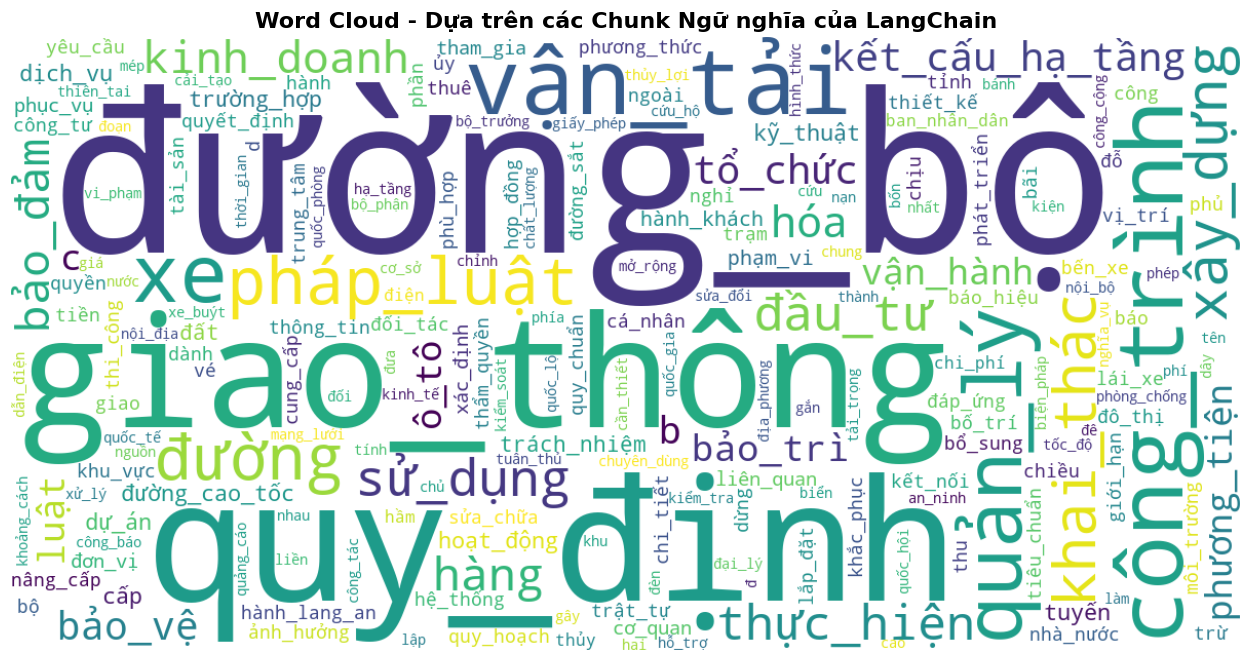


✅ Đã lưu Word Cloud vào: C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot\data\processed\wordcloud_langchain_chunks.png


In [14]:
# Gộp tất cả các chunk thành một chuỗi duy nhất
all_chunks_text = " ".join(text_chunks)

print("🌥️  Đang tạo Word Cloud từ các chunks...")

# Tạo đối tượng WordCloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis",
    collocations=False, # Không ghép các từ lại với nhau
)

# Generate word cloud từ chuỗi text
wc.generate(all_chunks_text)

# Hiển thị hình ảnh
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Dựa trên các Chunk Ngữ nghĩa của LangChain", fontsize=16, fontweight="bold")
plt.show()

# Lưu hình ảnh
output_path = BASE_DIR / "data" / "processed" / "wordcloud_langchain_chunks.png"
wc.to_file(output_path)

print(f"\n✅ Đã lưu Word Cloud vào: {output_path}")


## 3. Đánh giá và Phân tích độ dài Chunks

Sau khi tạo chunks, chúng ta cần đánh giá xem chúng có phân phối độ dài như thế nào. Điều này giúp kiểm tra xem `chunk_size` và `chunk_overlap` đã hợp lý chưa.

- **Biểu đồ Histogram**: Cho thấy tần suất của các chunk theo độ dài.
- **Các độ đo thống kê**: Trung bình, trung vị, min, max...
- **Độ lệch (Skewness)**:
  - `Skew > 0`: Lệch phải (đuôi dài bên phải) -> Hầu hết các chunk có độ dài nhỏ hơn trung bình.
  - `Skew < 0`: Lệch trái (đuôi dài bên trái) -> Hầu hết các chunk có độ dài lớn hơn trung bình.
  - `Skew ≈ 0`: Phân phối gần đối xứng.

📊 THỐNG KÊ ĐỘ DÀI CÁC CHUNKS (theo ký tự)
count    225.000000
mean     720.013333
std      136.984276
min      306.000000
25%      691.000000
50%      793.000000
75%      797.000000
max      799.000000
Name: chunk_length, dtype: float64
Median (Trung vị): 793.00
Skewness (Độ lệch): -1.68
-> Nhận xét: Phân phối lệch trái (Left-skewed).


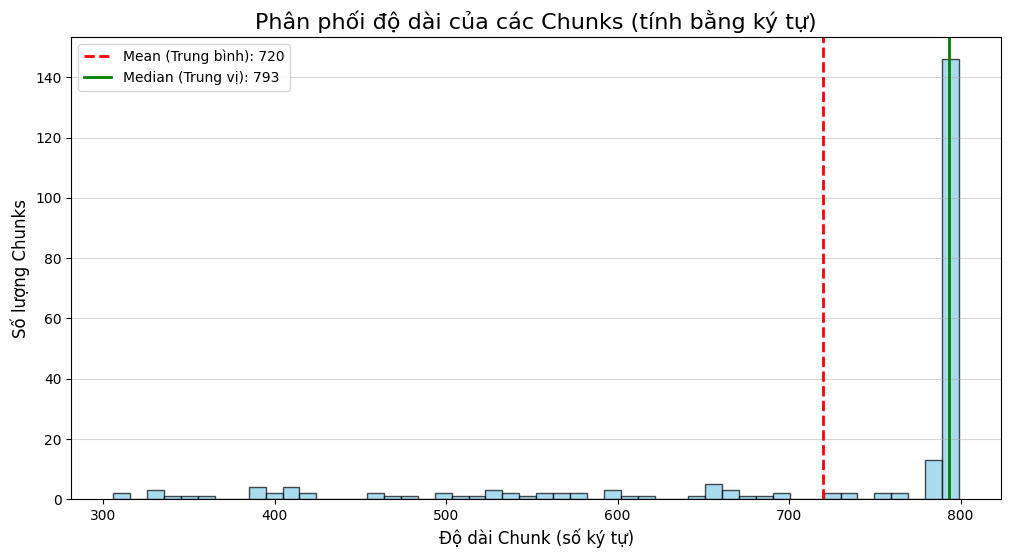

In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tính độ dài của mỗi chunk (theo số ký tự)
chunk_lengths = [len(chunk) for chunk in text_chunks]

# 2. Tạo DataFrame để dễ dàng tính toán thống kê
df_lengths = pd.DataFrame(chunk_lengths, columns=['chunk_length'])

# 3. Tính các độ đo thống kê
stats = df_lengths['chunk_length'].describe()
median = df_lengths['chunk_length'].median()
skewness = df_lengths['chunk_length'].skew()

print("📊 THỐNG KÊ ĐỘ DÀI CÁC CHUNKS (theo ký tự)")
print("="*45)
print(stats)
print(f"Median (Trung vị): {median:.2f}")
print(f"Skewness (Độ lệch): {skewness:.2f}")

if skewness > 0.5:
    print("-> Nhận xét: Phân phối lệch phải (Right-skewed).")
elif skewness < -0.5:
    print("-> Nhận xét: Phân phối lệch trái (Left-skewed).")
else:
    print("-> Nhận xét: Phân phối gần đối xứng.")

# 4. Vẽ biểu đồ Histogram
plt.figure(figsize=(12, 6))
plt.hist(df_lengths['chunk_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Thêm các đường dọc cho trung bình và trung vị
plt.axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f"Mean (Trung bình): {stats['mean']:.0f}")
plt.axvline(median, color='green', linestyle='-', linewidth=2, label=f"Median (Trung vị): {median:.0f}")

plt.title('Phân phối độ dài của các Chunks (tính bằng ký tự)', fontsize=16)
plt.xlabel('Độ dài Chunk (số ký tự)', fontsize=12)
plt.ylabel('Số lượng Chunks', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()
